# 01 — Quickstart: From PDF to Knowledge Graph

**Segment 3 · 20–50 min**

In this notebook we:
1. Define a Pydantic schema for a home insurance declarations page
2. Run the extraction pipeline (local gemma4 or remote GPT)
3. Explore the resulting knowledge graph
4. Query the graph to answer structured questions
5. Compare graph traversal against traditional vector search (RAG)

**The question we want to answer:**  
> *"List all coverages for this homeowner and their limits."*

We'll see what RAG returns — then what the graph returns. That contrast is the point.

---
## Part A — The Schema

The entire extraction is driven by a Pydantic schema.  
**The rule:** a field typed as another `BaseModel` becomes a graph edge.

```
HomePolicy
  ├── insurer    → Insurer      (INSURER edge)
  ├── insured    → Insured      (INSURED edge)
  ├── agent      → Agent        (AGENT edge)
  ├── coverages  → [Coverage]   (COVERAGES edges — one per coverage line)
  └── deductibles→ [Deductible] (DEDUCTIBLES edges)
```

No graph code. No manual parsing. Just Pydantic.

In [1]:
from pydantic import BaseModel, ConfigDict, Field
from typing import List, Optional

class Insurer(BaseModel):
    model_config = ConfigDict(graph_id_fields=["name"])
    name: str = Field(description="Insurance company name")
    address: Optional[str] = Field(default=None)
    phone: Optional[str] = Field(default=None)

class Insured(BaseModel):
    model_config = ConfigDict(graph_id_fields=["name"])
    name: str = Field(description="Full name(s) of insured")
    address: Optional[str] = Field(default=None)

class Agent(BaseModel):
    model_config = ConfigDict(graph_id_fields=["name"])
    name: str = Field(description="Agent name")
    agent_number: Optional[str] = Field(default=None)
    phone: Optional[str] = Field(default=None)

class Coverage(BaseModel):
    model_config = ConfigDict(graph_id_fields=["coverage_code"])
    coverage_code: str = Field(description="e.g. 'Coverage A', 'Coverage B'")
    coverage_name: str = Field(description="e.g. 'Dwelling', 'Personal Property'")
    limit: Optional[str] = Field(default=None, description="e.g. '$160,000'")
    premium: Optional[str] = Field(default=None, description="e.g. '$859.00' or 'Included'")

class Deductible(BaseModel):
    model_config = ConfigDict(graph_id_fields=["peril_type"])
    peril_type: str = Field(description="e.g. 'All Other Perils', 'Hurricane'")
    amount: Optional[str] = Field(default=None, description="e.g. '$1,000' or '2% of Coverage A'")

class HomePolicy(BaseModel):
    """Root entity — home insurance declarations page."""
    model_config = ConfigDict(graph_id_fields=["policy_number"])
    policy_number: str = Field(description="e.g. 'FHO295000'")
    policy_form: Optional[str] = Field(default=None, description="e.g. 'HO-3'")
    effective_date: Optional[str] = Field(default=None)
    expiration_date: Optional[str] = Field(default=None)
    total_premium: Optional[str] = Field(default=None)

    # These fields become graph edges ↓
    insurer: Optional[Insurer] = Field(default=None)
    insured: Optional[Insured] = Field(default=None)
    agent: Optional[Agent] = Field(default=None)
    coverages: List[Coverage] = Field(default_factory=list,
        description="All coverage lines from the declarations page")
    deductibles: List[Deductible] = Field(default_factory=list)

print("Schema defined. Fields typed as BaseModel subclasses → graph edges.")

Schema defined. Fields typed as BaseModel subclasses → graph edges.


---
## Part B — Run the Extraction

The pipeline does three things:
1. **docling** converts the PDF to clean markdown text  
2. **LLM** reads the text and extracts structured entities matching your schema  
3. **docling-graph** converts those entities into a NetworkX graph  

Expected time: ~2.7 min (gemma4 local) · ~20s (GPT remote)

### PipelineConfig — what each argument does

| Argument | What it controls |
|---|---|
| `source` | Path to the input document (PDF, Word, HTML, image) |
| `backend` | Extraction engine — `"llm"` uses a language model, `"vlm"` uses a vision model (see notebook 04) |
| `inference` | Where the model runs — `"local"` via Ollama, `"remote"` via API |
| `provider_override` | Which LLM provider — `"ollama"`, `"openai"`, `"anthropic"`, etc. |
| `model_override` | Exact model name — `"gemma4-8k"`, `"gpt-4o-mini"`, etc. |
| `template` | Your Pydantic schema class — this is both the extraction prompt and the graph definition |
| `use_chunking` | `False` = send the whole document as one prompt (good for ≤1 page). `True` = split into chunks and merge results (required for multi-page docs) |
| `extraction_contract` | `"direct"` = single LLM call on full text, fast. `"delta"` = chunked multi-pass with quality gates |
| `structured_output` | `True` = use JSON schema enforcement (OpenAI/Gemini). `False` = embed schema in prompt (local/Ollama models) |
| `dump_to_disk` | Save `graph.json`, `nodes.csv`, `edges.csv`, `report.md` to `output_dir` |
| `output_dir` | Where to write the output files |
| `llm_overrides` | Fine-grained reliability settings — timeout, retries, etc. |

In [2]:
# ── Configuration — edit these before running ─────────────────────────────────

# Set to True to run extraction even if a pre-run graph already exists.
FORCE_RUN = True

# Provider override:
#   None     → auto-detect from .env (OpenAI key if present, otherwise local gemma4-8k)
#   "openai" → force GPT-4o-mini  (requires OPENAI_API_KEY in .env)
#   "local"  → force local gemma4-8k via Ollama
#   "qwen"   → force local qwen3.5-2b via Ollama (lightweight, ~2.7 GB)
PROVIDER = 'local'

print(f"FORCE_RUN = {FORCE_RUN}")
print(f"PROVIDER  = {PROVIDER!r}  (None = auto-detect)")

FORCE_RUN = True
PROVIDER  = 'local'  (None = auto-detect)


In [3]:
import os
import time
import sys
import json
import networkx as nx
from pathlib import Path

sys.path.insert(0, str(Path("../").resolve()))

from dotenv import load_dotenv
from docling_graph import run_pipeline, PipelineConfig
from docling_graph.llm_clients.config import LlmRuntimeOverrides, ReliabilityOverrides

load_dotenv("../.env")

SOURCE = Path("../data/sample-declarations-page.pdf")
PRERUN = Path("../data/prerun/home_policy_graph.json")

# ── qwen3 monkey-patch ────────────────────────────────────────────────────────
# Only installed when PROVIDER == 'qwen'. Installing it globally causes LiteLLM's
# internal retry logic to recurse infinitely when used with other providers.
if (PROVIDER or '').lower() == 'qwen' or os.getenv('LLM_PROVIDER','').lower() == 'qwen':
    import litellm as _litellm
    _orig_completion = _litellm.completion
    def _completion_no_think(*args, **kwargs):
        kwargs.setdefault("extra_body", {})["think"] = False
        return _orig_completion(*args, **kwargs)
    _litellm.completion = _completion_no_think

# ── Provider resolution ───────────────────────────────────────────────────────
_provider  = (PROVIDER or os.getenv("LLM_PROVIDER", "")).lower()
openai_key = os.getenv("OPENAI_API_KEY", "")

if _provider == "openai" or (_provider != "local" and _provider != "qwen" and not _provider and openai_key):
    inference, provider_override, model = "remote", "openai", "gpt-4o-mini"
    structured_output, timeout = True, 120
elif _provider == "qwen":
    inference, provider_override, model = "local", "ollama", "qwen3.5-2b"
    structured_output, timeout = False, 300
else:
    inference, provider_override, model = "local", "ollama", "gemma4-8k"
    structured_output, timeout = False, 300

print(f"Provider: {provider_override} / {model}")
print(f"Source:   {SOURCE.name}  ({SOURCE.stat().st_size // 1024} KB)")


Provider: ollama / gemma4-8k
Source:   sample-declarations-page.pdf  (157 KB)


In [4]:
# ── Run pipeline or load pre-run ──────────────────────────────────────────────
def load_graph_json(path: Path) -> nx.DiGraph:
    with open(path) as f:
        data = json.load(f)
    G = nx.DiGraph()
    for node in data["nodes"]:
        node = dict(node)
        nid = node.pop("id")
        G.add_node(nid, **node)
    for edge in data["edges"]:
        G.add_edge(edge["source"], edge["target"],
                   relation=edge.get("relation") or edge.get("label", ""))
    return G

if not FORCE_RUN and PRERUN.exists():
    print("Pre-run graph found. Set FORCE_RUN = True in the config cell above to re-run extraction.")
    print("Loading pre-run graph...")
    G = load_graph_json(PRERUN)
    print(f"Loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
else:
    config = PipelineConfig(
        source=SOURCE,                    # input PDF
        backend="llm",                    # use language model (not vision model)
        inference=inference,              # "local" (Ollama) or "remote" (API)
        provider_override=provider_override,  # "ollama", "openai", "anthropic", ...
        model_override=model,             # exact model name, e.g. "gemma4-8k"
        template=HomePolicy,              # your Pydantic schema → extraction prompt + graph shape
        use_chunking=False,               # single page: send the full doc in one LLM call
        extraction_contract="direct",     # "direct" = one call, fast; "delta" = chunked multi-pass
        structured_output=structured_output,  # True = JSON schema mode (OpenAI); False = prompt mode (Ollama)
        dump_to_disk=True,                # write graph.json, nodes.csv, edges.csv, report.md
        output_dir=Path("../data/home_policy_output") / model,  # where to save outputs
        llm_overrides=LlmRuntimeOverrides(
            reliability=ReliabilityOverrides(
                timeout_s=timeout         # 300s for local, 120s for remote
            )
        ),
    )
    t0 = time.perf_counter()
    print("Running extraction...")
    ctx = run_pipeline(config)
    elapsed = time.perf_counter() - t0
    G = ctx.knowledge_graph
    print(f"Done in {elapsed:.1f}s — {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Running extraction...


[LlmBackend] Initialized with:
  • Client: LiteLLMClient
  • Model: gemma4-8k

[DocumentProcessor] Initialized with Classic OCR pipeline (English, French)

[ExtractorFactory] Created ManyToOneStrategy

[DocumentProcessor] Converting document: ../data/sample-declarations-page.pdf

...

[GraphConverter] Final graph: 18 nodes, 17 edges
  Registry: 18 entities across 6 classes

→ Saved conversion results to ../data/home_policy_output/gemma4-8k/sample-declarations-page_pdf_20260418_111322

[LlmBackend] Cleaned up resources

[DocumentProcessor] Cleaned up resources

Done in 134.1s — 18 nodes, 17 edges


---
## Part C — Explore the Graph

In [5]:
from collections import Counter

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges\n")

print("Node types:")
for t, n in Counter(d.get("__class__") for _, d in G.nodes(data=True)).most_common():
    print(f"  {t or '—':<20s} × {n}")

print("\nEdge types:")
for r, n in Counter(d.get("relation") for _, _, d in G.edges(data=True)).most_common():
    print(f"  {r or '—':<20s} × {n}")

Graph: 18 nodes, 17 edges

Node types:
  Coverage             × 11
  Deductible           × 3
  Insurer              × 1
  Insured              × 1
  Agent                × 1
  HomePolicy           × 1

Edge types:
  —                    × 17


In [6]:
# ASCII tree — shows the graph structure at a glance
sys.path.insert(0, str(Path("../").resolve()))
from graph_utils import print_graph_tree

print_graph_tree(G)


────────────────────────────────────────────────────────────
  Graph tree  (18 nodes · 17 edges)
────────────────────────────────────────────────────────────

[HomePolicy] FHO295000
├── INSURER  [Insurer] SAFE ALL INSURANCE COMPANY
├── INSURED  [Insured] Estelle Clarion & James Delaney
├── AGENT  [Agent] TONY PRIZE
├── COVERAGE  [Coverage]
├── COVERAGE  [Coverage]
├── COVERAGE  [Coverage]
├── COVERAGE  [Coverage]
├── COVERAGE  [Coverage]
├── COVERAGE  [Coverage]
├── COVERAGE  [Coverage]
├── COVERAGE  [Coverage]
├── COVERAGE  [Coverage]
├── COVERAGE  [Coverage]
├── COVERAGE  [Coverage]
├── DEDUCTIBLES  [Deductible] → $1,000
├── DEDUCTIBLES  [Deductible] → 2% of Coverage A
└── DEDUCTIBLES  [Deductible]

  Node types: Coverage×11 · Deductible×3 · Insurer×1 · Insured×1 · Agent×1 · HomePolicy×1
────────────────────────────────────────────────────────────


In [7]:
# Generate interactive HTML graph
import sys, importlib
sys.path.insert(0, str(Path("../").resolve()))
import visualize_graph as vg
importlib.reload(vg)  # always picks up latest changes without kernel restart

out_path = Path("../data/home_policy_output/graph_pretty.html").resolve()
out_path.parent.mkdir(parents=True, exist_ok=True)
vg.make_interactive(G, out_path)

try:
    vg.make_summary_chart(G, out_path.with_suffix(".png"))
except Exception as e:
    print(f"Summary chart skipped ({e.__class__.__name__}: {e})")

print(f"Graph saved → {out_path}")


Interactive graph → /Users/krishrekapalli/dev/git/docling-graph-tutorial/data/home_policy_output/graph_pretty.html
Summary chart     → /Users/krishrekapalli/dev/git/docling-graph-tutorial/data/home_policy_output/graph_pretty.png
Graph saved → /Users/krishrekapalli/dev/git/docling-graph-tutorial/data/home_policy_output/graph_pretty.html


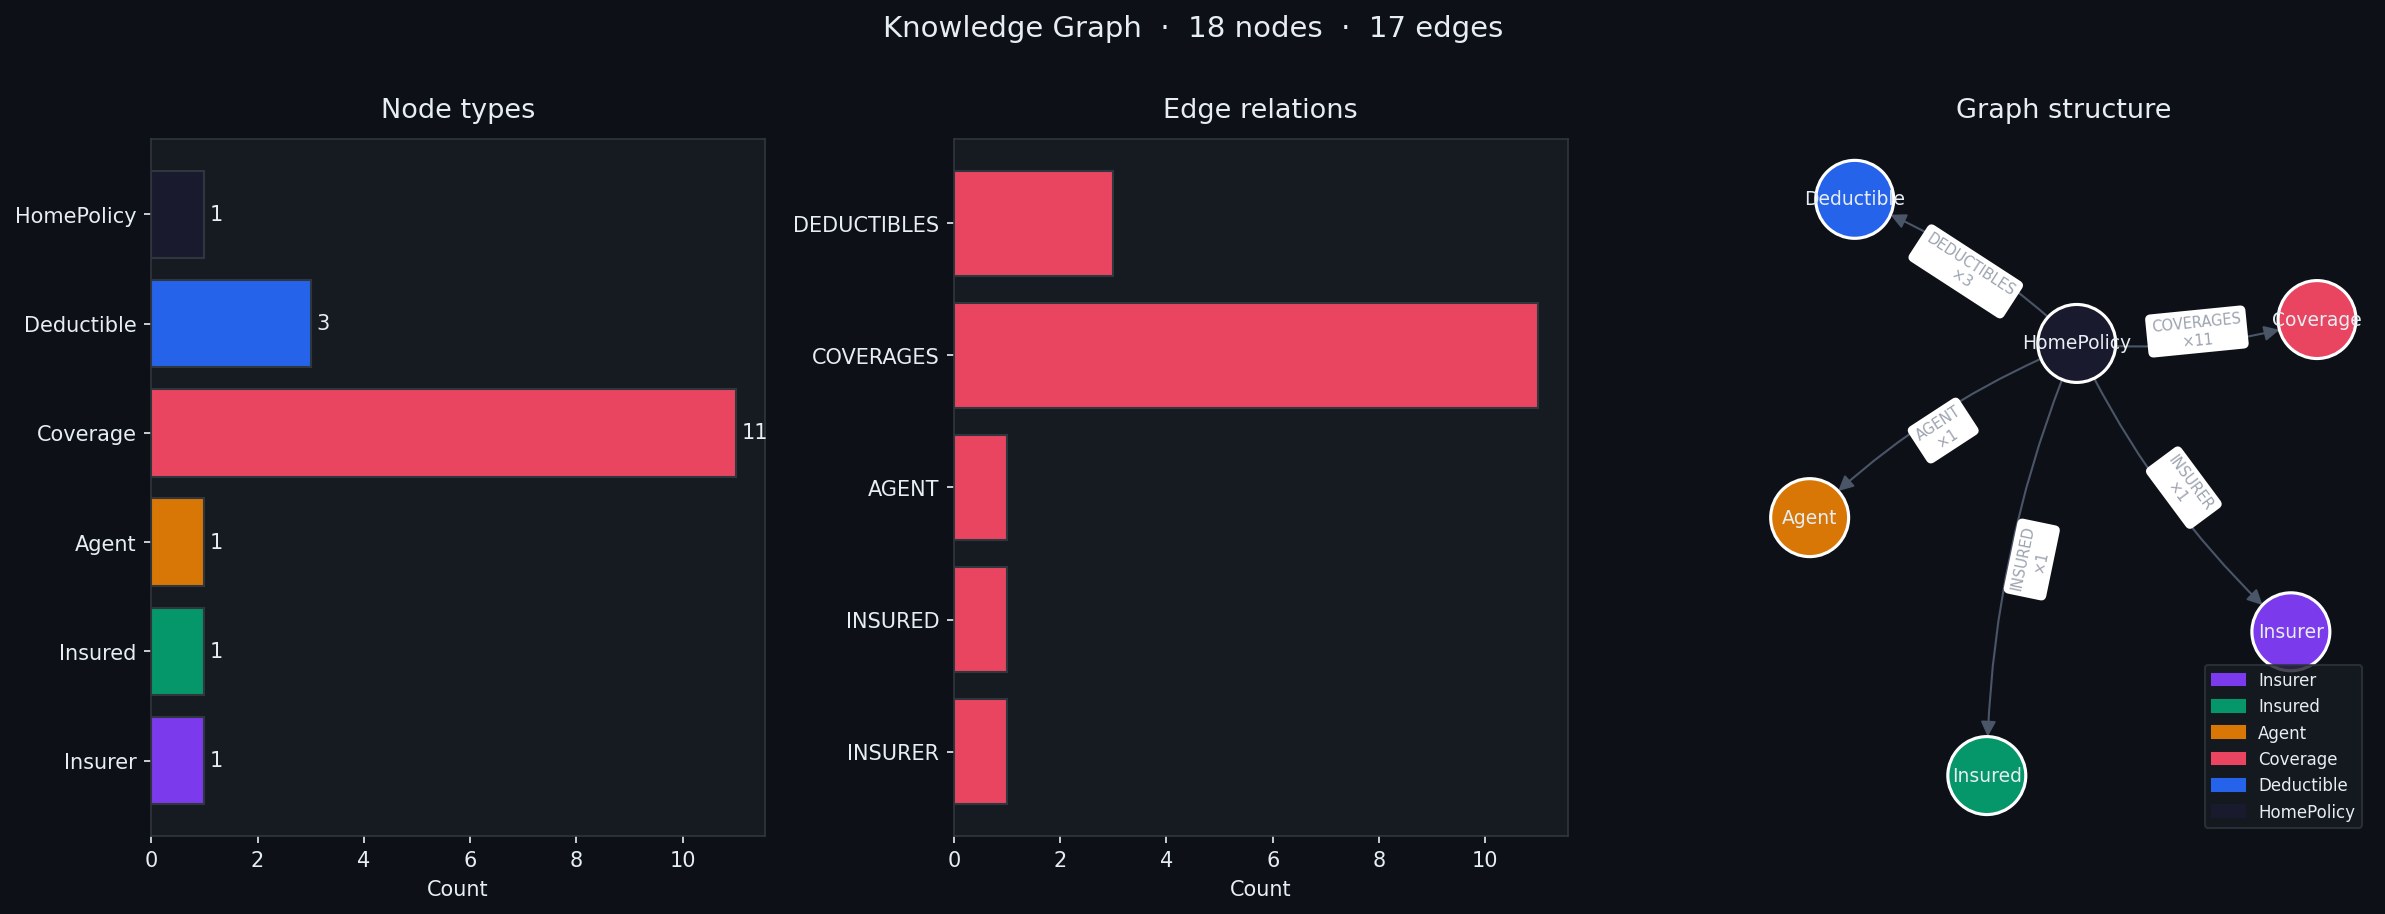

Opened in browser: /Users/krishrekapalli/dev/git/docling-graph-tutorial/data/home_policy_output/graph_pretty.html


In [8]:
# Show summary chart inline; open the interactive graph in the default browser
import webbrowser
from IPython.display import Image, display

# Static summary chart — renders in VS Code
display(Image(str(out_path.with_suffix(".png")), width=700))

# Interactive graph — opens in default system browser
webbrowser.open(out_path.resolve().as_uri())
print(f"Opened in browser: {out_path.resolve()}")

---
## Part D — Query the Graph

Now let's answer the question we started with.  
With a knowledge graph, the answer is a simple traversal — no parsing, no ambiguity.

In [9]:
# Question: "List all coverages and their limits for this homeowner"

coverages = [
    {
        "code":    d.get("coverage_code", "—"),
        "name":    d.get("coverage_name", "—"),
        "limit":   d.get("limit", "—"),
        "premium": d.get("premium", "—"),
    }
    for _, d in G.nodes(data=True)
    if d.get("__class__") == "Coverage"
]

print(f"Found {len(coverages)} coverages:\n")
print(f"{'Code':<20} {'Name':<35} {'Limit':<15} {'Premium'}")
print("-" * 80)
for c in sorted(coverages, key=lambda x: x["code"]):
    print(f"{c['code']:<20} {c['name']:<35} {c['limit']:<15} {c['premium']}")

Found 11 coverages:

Code                 Name                                Limit           Premium
--------------------------------------------------------------------------------
All Other Perils (other than Hurricane) All Other Perils (other than Hurricane) $1,000          None
Coverage A           Dwelling                            $160,000        $859.00
Coverage B           Other Structures                    $3,200          Included
Coverage C           Personal Property                   $104,250        Included
Coverage D           Loss of Use                         $20,850         Included
Coverage E           Personal Liability                  $100,000        Included
Coverage F           Medical Payments                    $1,000          Included
HURRICANE            HURRICANE                           $3,200          None
Ordinance or Law     Ordinance or Law                    $40,000         -57.00
Sinkhole             Sinkhole                            Not Includ

In [10]:
# Question: "What are the deductibles on this policy?"

deductibles = [
    (d.get("peril_type", "—"), d.get("amount", "—"))
    for _, d in G.nodes(data=True)
    if d.get("__class__") == "Deductible"
]

print("Deductibles:\n")
for peril, amount in deductibles:
    print(f"  {peril:<35} {amount}")

Deductibles:

  All Other Perils (other than Hurricane) $1,000
  HURRICANE                           2% of Coverage A
  Sinkhole                            None


In [11]:
# Question: "Which coverages are included in the base premium (no extra charge)?"

included = [
    d.get("coverage_name")
    for _, d in G.nodes(data=True)
    if d.get("__class__") == "Coverage"
    and str(d.get("premium", "")).lower() == "included"
]

print("Coverages included in base premium:")
for name in included:
    print(f"  • {name}")

Coverages included in base premium:
  • Other Structures
  • Personal Property
  • Loss of Use
  • Personal Liability
  • Medical Payments


In [12]:
# Multi-hop: Who is the insurer for this policy, and what is the policyholder's address?

for node_id, data in G.nodes(data=True):
    if data.get("__class__") == "HomePolicy":
        print(f"Policy:  #{data.get('policy_number')}  ({data.get('policy_form')})")
        print(f"Period:  {data.get('effective_date')} → {data.get('expiration_date')}")
        print(f"Premium: {data.get('total_premium')}")

        # Traverse edges to find connected entities
        for _, target, edata in G.out_edges(node_id, data=True):
            tdata = G.nodes[target]
            cls = tdata.get("__class__", "")
            if cls in ("Insurer", "Insured", "Agent"):
                print(f"\n{edata.get('relation','→'):12} {tdata.get('name')}")
                if tdata.get("address"):
                    print(f"{'':12} {tdata['address']}")
                if tdata.get("phone"):
                    print(f"{'':12} {tdata['phone']}")

Policy:  #FHO295000  (HO-3)
Period:  3/28/20 → 3/28/2021
Premium: $854.00

→            SAFE ALL INSURANCE COMPANY
             P.O. Box 1075 Thiston, FL 12345-6789
             (123) 456-7891

→            Estelle Clarion & James Delaney
             596 Crossover Way Clay, FL 17189-2021

→            TONY PRIZE
             (123) 456-7891


---
## Part E — Graph vs RAG: Live Comparison

We'll ask the same question two ways:

1. **RAG (retrieval only)** — split the document into chunks, embed with sentence-transformers,  
   find the closest chunks by cosine similarity  
2. **Graph** — traverse the nodes we just built  

**Note:** This is retrieval, not generation — we're not calling an LLM to answer.  
That's intentional: we want to compare *what information each approach surfaces*, not how well an LLM narrates it.

**No vector database** — embeddings live in a tensor in memory. For 5 chunks, that's all you need.  
In production you'd use FAISS or Chroma; the retrieval logic is identical.

Same document. Same question. Different answers.

In [13]:
# Step 1: Extract raw text from the PDF and split into chunks
from docling.document_converter import DocumentConverter

print("Extracting text from PDF...")
converter = DocumentConverter()
result = converter.convert(str(SOURCE))
full_text = result.document.export_to_markdown()

# Split into paragraph-level chunks
chunks = [c.strip() for c in full_text.split("\n\n") if len(c.strip()) > 40]
print(f"Document split into {len(chunks)} chunks")
print(f"\nSample chunk:\n{chunks[2][:300]}")

Extracting text from PDF...


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

Document split into 5 chunks

Sample chunk:
Estelle Clarion &amp; James Delaney 596 Crossover Way Clay, FL 17189-2021


In [14]:
# Step 2: Embed chunks with sentence-transformers
import logging
import transformers
# Suppress the harmless "embeddings.position_ids UNEXPECTED" load report
transformers.logging.set_verbosity_error()
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)

from sentence_transformers import SentenceTransformer, util

print("Loading embedding model (all-MiniLM-L6-v2)...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

chunk_embeddings = embedder.encode(chunks, convert_to_tensor=True, show_progress_bar=False)
print(f"Embedded {len(chunks)} chunks")

Loading embedding model (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedded 5 chunks


In [15]:
# Step 3: Ask the question via RAG
query = "List all coverages and their coverage limits for this homeowner"
query_embedding = embedder.encode(query, convert_to_tensor=True)

scores = util.cos_sim(query_embedding, chunk_embeddings)[0]
top_k = scores.topk(3)

print(f'Query: "{query}"')
print("\n" + "=" * 60)
print("RAG RESULT — Top 3 matching chunks:")
print("=" * 60)
for rank, (score, idx) in enumerate(zip(top_k.values, top_k.indices), 1):
    print(f"\n[Chunk {rank}  score={score:.3f}]")
    print(chunks[idx][:400])
    if len(chunks[idx]) > 400:
        print("...")

Query: "List all coverages and their coverage limits for this homeowner"

RAG RESULT — Top 3 matching chunks:

[Chunk 1  score=0.335]
| TOTAL ANNUAL POLICY PREMIUM:                                                                                              | TOTAL ANNUAL POLICY PREMIUM:                                                                                              | TOTAL ANNUAL POLICY PREMIUM:                                                                                              | $854.00   |
|-------------
...

[Chunk 2  score=0.213]
P.O. Box 1075 Thiston, FL 12345-6789 (123) 456-7891

[Chunk 3  score=0.164]
Apollo Savings Mortgage Co P.O. Box 120140, Dept. 12 Leto, TX, 22231


In [16]:
# Step 4: Ask the same question via graph traversal
print("=" * 60)
print("GRAPH RESULT — Direct traversal:")
print("=" * 60)
print(f"\nFound {len(coverages)} coverages:\n")
print(f"{'Code':<20} {'Name':<35} {'Limit':<15} {'Premium'}")
print("-" * 80)
for c in sorted(coverages, key=lambda x: x["code"]):
    print(f"{c['code']:<20} {c['name']:<35} {c['limit']:<15} {c['premium']}")

GRAPH RESULT — Direct traversal:

Found 11 coverages:

Code                 Name                                Limit           Premium
--------------------------------------------------------------------------------
All Other Perils (other than Hurricane) All Other Perils (other than Hurricane) $1,000          None
Coverage A           Dwelling                            $160,000        $859.00
Coverage B           Other Structures                    $3,200          Included
Coverage C           Personal Property                   $104,250        Included
Coverage D           Loss of Use                         $20,850         Included
Coverage E           Personal Liability                  $100,000        Included
Coverage F           Medical Payments                    $1,000          Included
HURRICANE            HURRICANE                           $3,200          None
Ordinance or Law     Ordinance or Law                    $40,000         -57.00
Sinkhole             Sinkhole    

### What did we just see?

| | RAG | Graph |
|---|---|---|  
| Returns | Text chunks | Structured rows |
| Complete? | Depends on chunk boundaries | Always — every Coverage node |
| Needs parsing? | Yes — extract values from text | No — fields are already typed |
| Countable? | Not directly | `len(coverages)` |
| Filterable? | Requires re-query | `if d["premium"] == "Included"` |

**RAG finds relevant text. Graphs answer relationship questions.**  
They're complementary — use both in production.

---
## What's Next

In `02_schema.ipynb` you'll build a schema for a new domain from scratch — NVIDIA earnings — and learn how `graph_id_fields` handles deduplication across document chunks.

**The one thing to remember:**  
> A Pydantic field typed as another `BaseModel` becomes a graph edge.  
> That's the whole trick.